In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print("Pandas:", pd.__version__)
print("Numpy:", np.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("Seaborn:", sns.__version__)

Pandas: 2.3.3
Numpy: 2.3.5
Matplotlib: 3.10.6
Seaborn: 0.13.2


In [3]:
df = pd.read_csv("../data/AB_NYC_2019.csv")

### Part A - Pliminary Data Analysis

In [4]:
df.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


In [5]:
df.shape

(48895, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

#### Answer No. 2

In [7]:
df.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

### Answer

The dataset contains numeric, categorical, free-text, and date-related columns.

**Numeric columns:** `id`, `host_id`, `latitude`, `longitude`, `price`,
`minimum_nights`, `number_of_reviews`, `reviews_per_month`,
`calculated_host_listings_count`, and `availability_365`.

**Categorical columns:** `neighbourhood_group`, `neighbourhood`, and
`room_type`.

**Free-text columns:** `name` and `host_name`.

**Date column:** `last_review`.

Although `id` and `host_id` are stored as numeric values, they are identifiers
rather than meaningful numerical predictors. The categorical variables will
later require encoding, while the free-text and date columns require special
handling before they can be used for modeling.

#### Answer No 3

In [8]:
missing_count = df.isnull().sum()

In [9]:
missing_count

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [10]:
missing_percentage = (df.isnull().sum() /len(df)) * 100

In [11]:
missing_percentage

id                                 0.000000
name                               0.032723
host_id                            0.000000
host_name                          0.042949
neighbourhood_group                0.000000
neighbourhood                      0.000000
latitude                           0.000000
longitude                          0.000000
room_type                          0.000000
price                              0.000000
minimum_nights                     0.000000
number_of_reviews                  0.000000
last_review                       20.558339
reviews_per_month                 20.558339
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64

In [12]:
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() /len(df)) * 100
})
missing_summary

,Missing Count,Missing Percentage
id,0,0.000000
name,16,0.032723
host_id,0,0.000000
host_name,21,0.042949
neighbourhood_group,0,0.000000
neighbourhood,0,0.000000
latitude,0,0.000000
longitude,0,0.000000
room_type,0,0.000000
price,0,0.000000


In [13]:
missing_summary.sort_values(
    by='Missing Count',
    ascending=False
)

,Missing Count,Missing Percentage
last_review,10052,20.558339
reviews_per_month,10052,20.558339
host_name,21,0.042949
name,16,0.032723
id,0,0.000000
host_id,0,0.000000
neighbourhood_group,0,0.000000
neighbourhood,0,0.000000
latitude,0,0.000000
longitude,0,0.000000


#### Answer No 4

In [14]:
duplicate_rows = df.duplicated().sum()

In [15]:
duplicate_rows

np.int64(0)

#### Answer no 5

In [16]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


#### Answer no 6

In [17]:
df['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [18]:
df['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [19]:
df['neighbourhood'].nunique()

221

### Part B
#### Answer no 7

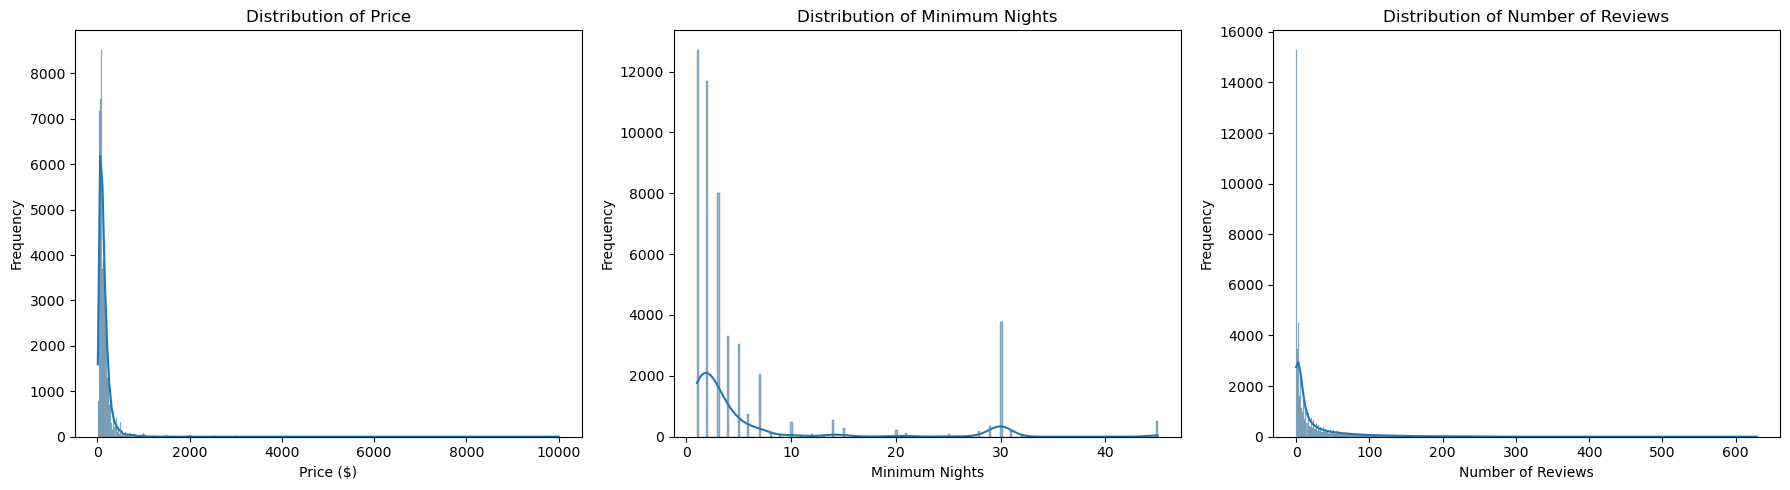

In [79]:
# Q7. Histograms with KDE

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['price'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Price')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')

sns.histplot(df['minimum_nights'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Minimum Nights')
axes[1].set_xlabel('Minimum Nights')
axes[1].set_ylabel('Frequency')

sns.histplot(df['number_of_reviews'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Number of Reviews')
axes[2].set_xlabel('Number of Reviews')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#### Answer No 8

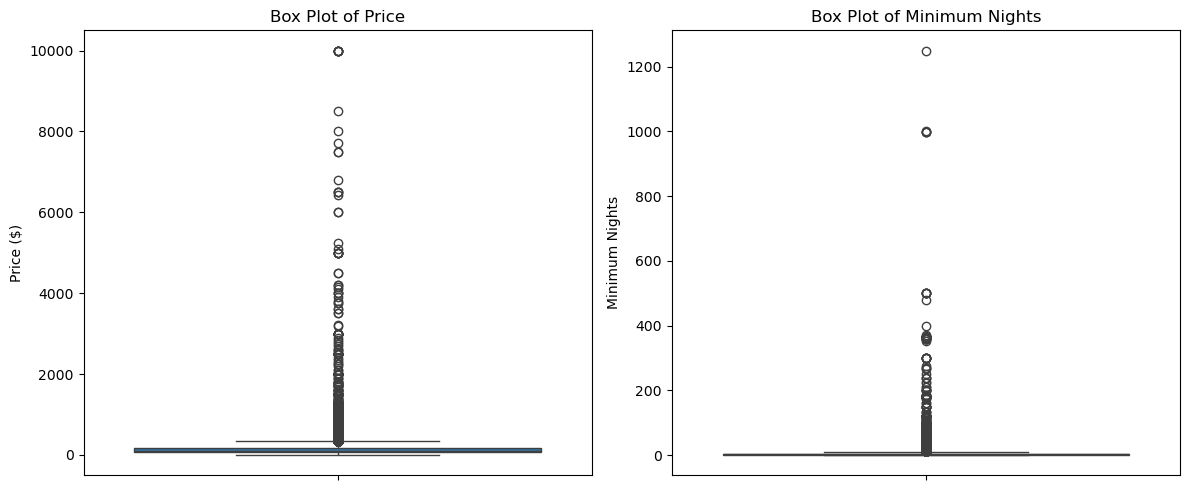

In [21]:
# Q8. Box plots for price and minimum_nights

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['price'], ax=axes[0])
axes[0].set_title('Box Plot of Price')
axes[0].set_ylabel('Price ($)')

sns.boxplot(y=df['minimum_nights'], ax=axes[1])
axes[1].set_title('Box Plot of Minimum Nights')
axes[1].set_ylabel('Minimum Nights')

plt.tight_layout()
plt.show()

In [22]:
# Calculate outliers using the 1.5 × IQR rule

for column in ['price', 'minimum_nights']:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"{column}:")
    print("Q1 =", Q1)
    print("Q3 =", Q3)
    print("IQR =", IQR)
    print("Lower bound =", lower_bound)
    print("Upper bound =", upper_bound)
    print("Number of outliers =", len(outliers))
    print()

price:
Q1 = 69.0
Q3 = 175.0
IQR = 106.0
Lower bound = -90.0
Upper bound = 334.0
Number of outliers = 2972

minimum_nights:
Q1 = 1.0
Q3 = 5.0
IQR = 4.0
Lower bound = -5.0
Upper bound = 11.0
Number of outliers = 6607



#### Answer No 9

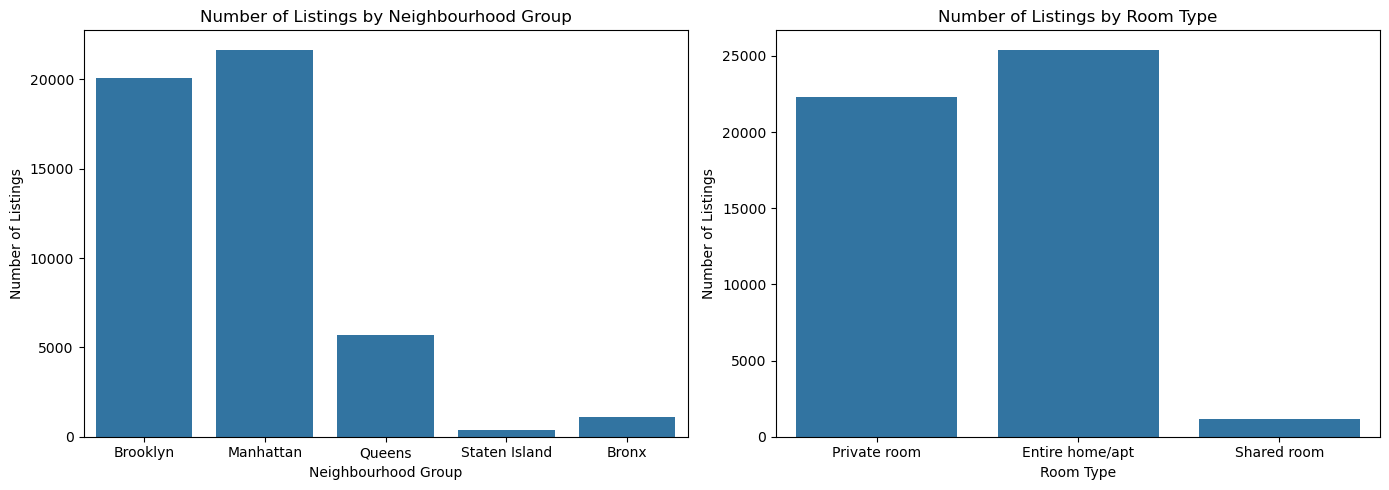

In [23]:
# Q9. Count plots for neighbourhood_group and room_type

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=df,
    x='neighbourhood_group',
    ax=axes[0]
)
axes[0].set_title('Number of Listings by Neighbourhood Group')
axes[0].set_xlabel('Neighbourhood Group')
axes[0].set_ylabel('Number of Listings')

sns.countplot(
    data=df,
    x='room_type',
    ax=axes[1]
)
axes[1].set_title('Number of Listings by Room Type')
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Number of Listings')

plt.tight_layout()
plt.show()

#### Answer No 10

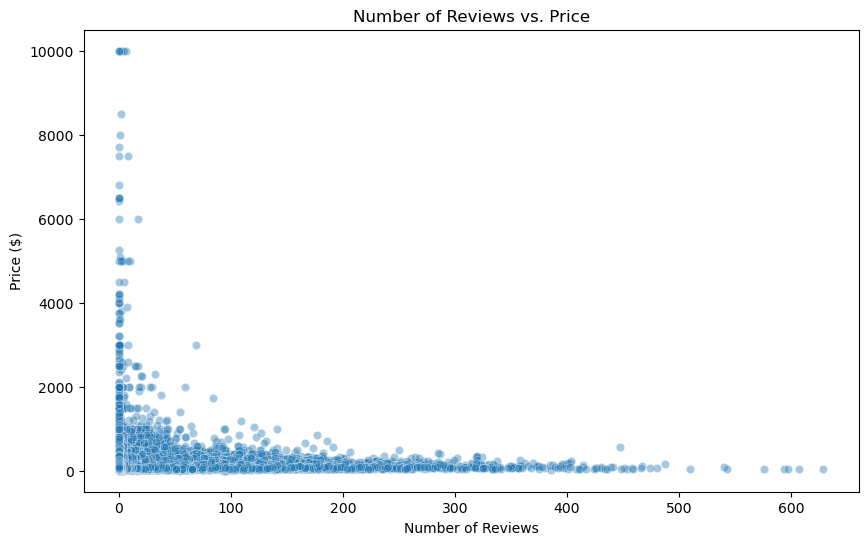

In [24]:
# Q10. Scatter plot of number_of_reviews vs price

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='number_of_reviews',
    y='price',
    alpha=0.4
)

plt.title('Number of Reviews vs. Price')
plt.xlabel('Number of Reviews')
plt.ylabel('Price ($)')
plt.show()

#### Answer No 11

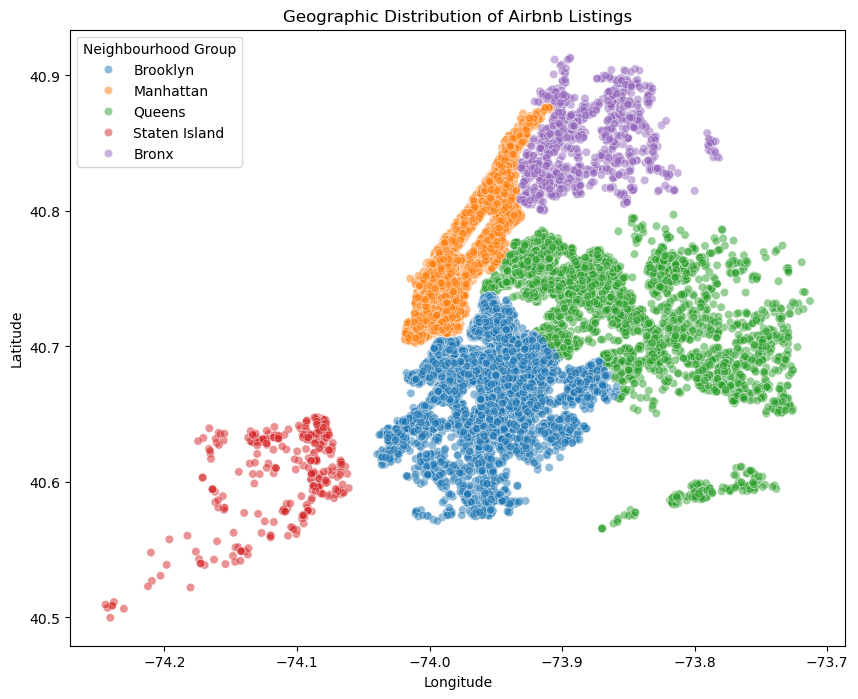

In [25]:
# Q11. Geographic distribution of listings colored by neighbourhood group

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='neighbourhood_group',
    alpha=0.5
)

plt.title('Geographic Distribution of Airbnb Listings')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Neighbourhood Group')
plt.show()

#### Answer No 12

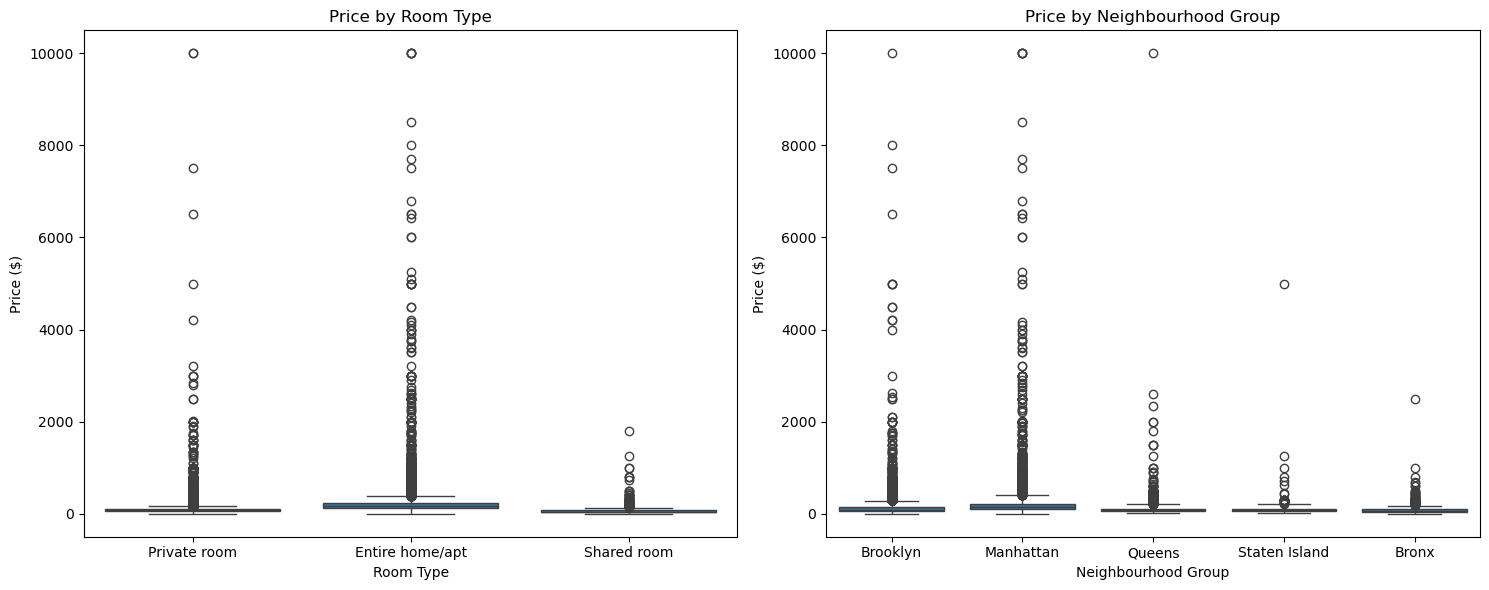

In [26]:
# Q12. Price by room type and neighbourhood group

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(
    data=df,
    x='room_type',
    y='price',
    ax=axes[0]
)

axes[0].set_title('Price by Room Type')
axes[0].set_xlabel('Room Type')
axes[0].set_ylabel('Price ($)')

sns.boxplot(
    data=df,
    x='neighbourhood_group',
    y='price',
    ax=axes[1]
)

axes[1].set_title('Price by Neighbourhood Group')
axes[1].set_xlabel('Neighbourhood Group')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

#### Answer No 13

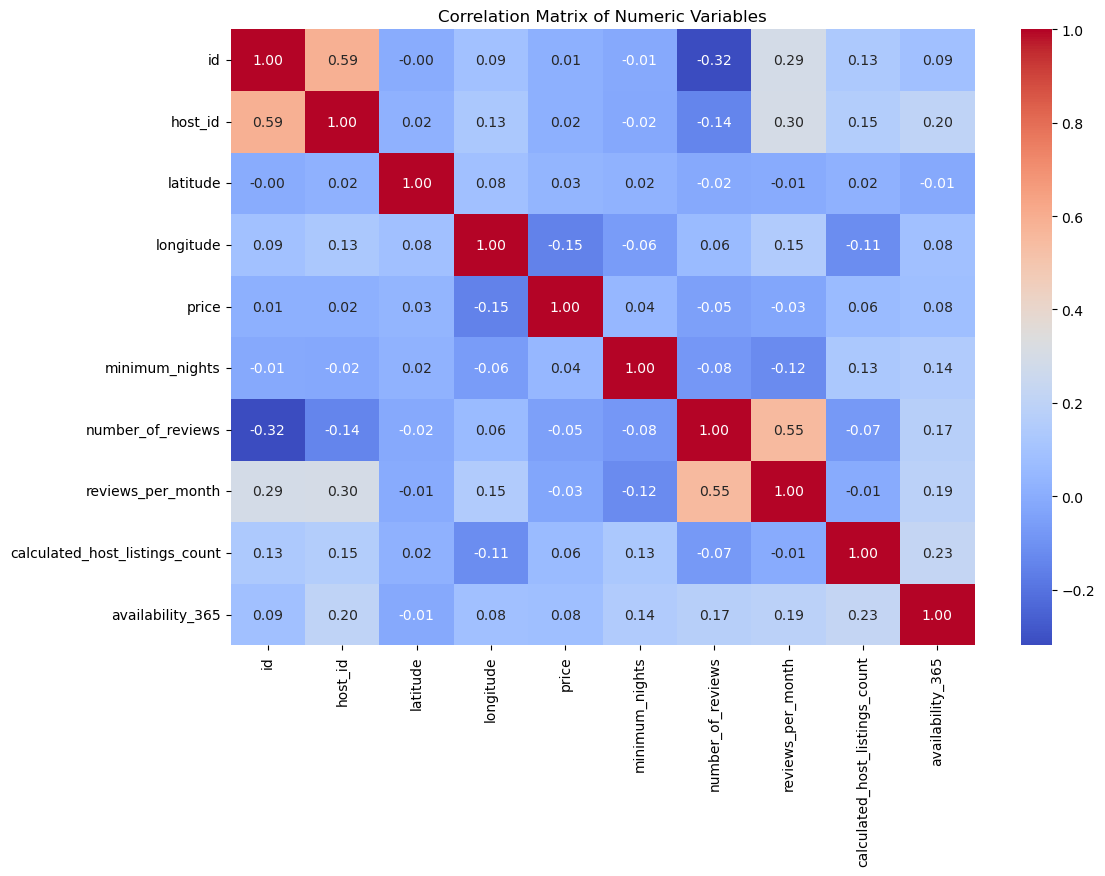

In [27]:
# Q13. Correlation matrix

numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Numeric Variables')
plt.show()

In [28]:
# Correlation of numeric variables with price

price_correlations = correlation_matrix['price'].sort_values(
    ascending=False
)

price_correlations

price                             1.000000
availability_365                  0.081829
calculated_host_listings_count    0.057472
minimum_nights                    0.042799
latitude                          0.033939
host_id                           0.015309
id                                0.010619
reviews_per_month                -0.030608
number_of_reviews                -0.047954
longitude                        -0.150019
Name: price, dtype: float64

#### Answer No 14

The data shows that Airbnb prices are very different from one listing to another. Price, minimum nights, and number of reviews are all right-skewed. There are also many outliers, especially in price and minimum nights. Most listings are located in Manhattan and Brooklyn. Room type has a clear relationship with price, with entire homes/apartments generally costing more than private or shared rooms. The number of reviews does not have a strong relationship with price. Among the numeric variables, longitude has the strongest correlation with price, but the correlation is still weak. Based on the EDA, I expect room type, neighbourhood, location, availability, and minimum nights to be useful for predicting Airbnb prices. The main data-quality problems are missing values, outliers, and skewed distributions.

### Part C
#### ANswer No 15

In [29]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

df = df.drop(columns=['last_review'])

print(df[['reviews_per_month']].isnull().sum())

reviews_per_month    0
dtype: int64


In [32]:
# Q16. Drop free-text columns

df = df.drop(columns=['name', 'host_name'])

KeyError: "['name', 'host_name'] not found in axis"

In [33]:
# Q17. Handle invalid price and extreme minimum nights

df = df[df['price'] > 0]

upper_limit = df['minimum_nights'].quantile(0.99)

df['minimum_nights'] = df['minimum_nights'].clip(
    upper=upper_limit
)

C:\Users\victus\AppData\Local\Temp\ipykernel_10584\2245684057.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['minimum_nights'] = df['minimum_nights'].clip(


In [34]:
# Q18. One-hot encode low-cardinality categorical variables

df = pd.get_dummies(
    df,
    columns=['room_type', 'neighbourhood_group'],
    drop_first=True
)

In [35]:

df = df.drop(columns=['neighbourhood'])

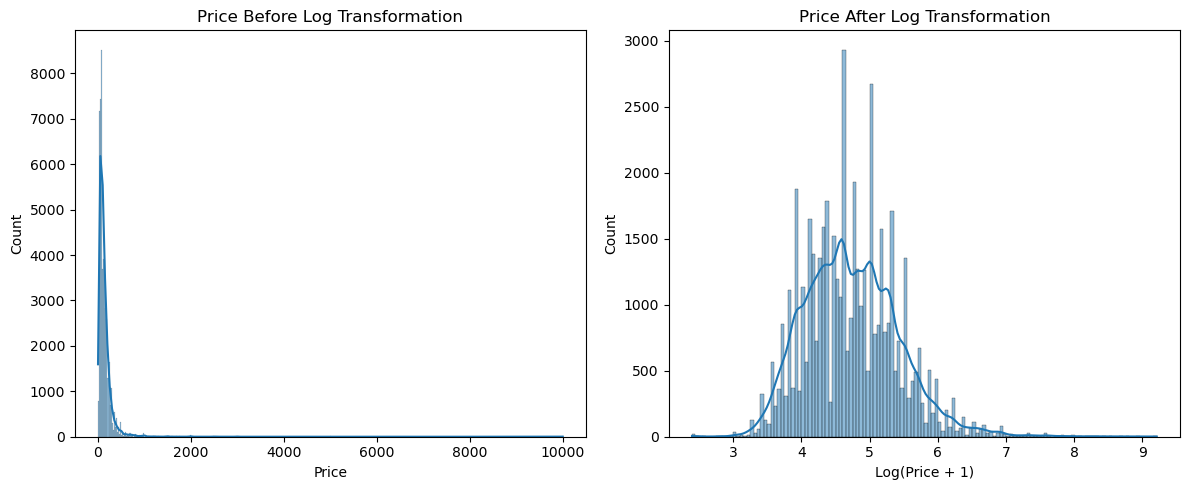

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['price'], kde=True, ax=axes[0])
axes[0].set_title('Price Before Log Transformation')
axes[0].set_xlabel('Price')

sns.histplot(np.log1p(df['price']), kde=True, ax=axes[1])
axes[1].set_title('Price After Log Transformation')
axes[1].set_xlabel('Log(Price + 1)')

plt.tight_layout()
plt.show()

In [37]:
print("Before:", df['price'].skew())
print("After:", np.log1p(df['price']).skew())

Before: 19.119026764709606
After: 0.6294448333542177


In [38]:
# Q20. Select features and target

X = df.drop(columns=['price', 'id', 'host_id'])

y = np.log1p(df['price'])

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (39107, 13)
Testing data: (9777, 13)


In [40]:
from sklearn.preprocessing import StandardScaler

numeric_features = [
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365'
]

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_test[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

In [41]:
scaler.fit_transform(X_train)

array([[-0.37808277,  3.54273116, -0.33937464, ..., -0.89271997,
         2.75726453, -0.08673445],
       [-0.46921484,  0.38979428, -0.12367622, ..., -0.89271997,
        -0.3626783 , -0.08673445],
       [ 3.13169414,  1.84973642, -0.44722385, ..., -0.89271997,
        -0.3626783 , -0.08673445],
       ...,
       [ 3.03726151,  1.18768478, -0.55507307, ..., -0.89271997,
        -0.3626783 , -0.08673445],
       [ 0.84459068, -0.60360868, -0.44722385, ...,  1.12017209,
        -0.3626783 , -0.08673445],
       [ 0.32181894,  0.14176903, -0.12367622, ..., -0.89271997,
         2.75726453, -0.08673445]], shape=(39107, 13))

In [42]:
scaler.transform(X_test)

array([[ 0.16064168, -0.9564425 ,  0.63126827, ...,  1.12017209,
        -0.3626783 , -0.08673445],
       [ 1.14420802,  0.11811658, -0.44722385, ...,  1.12017209,
        -0.3626783 , -0.08673445],
       [-0.18261637,  0.17670522,  2.57255409, ..., -0.89271997,
        -0.3626783 , -0.08673445],
       ...,
       [-1.34074557, -0.13967344, -0.23152543, ..., -0.89271997,
        -0.3626783 , -0.08673445],
       [-0.67641655,  1.07636636, -0.44722385, ..., -0.89271997,
        -0.3626783 , -0.08673445],
       [ 0.33062042,  1.22479092, -0.12367622, ..., -0.89271997,
         2.75726453, -0.08673445]], shape=(9777, 13))

### Part D

#### Answer No 22

In [54]:
# Q22. Simple Linear Regression

from sklearn.linear_model import LinearRegression

X_simple = df[['availability_365']]
y_simple = df['price']

simple_model = LinearRegression()

simple_model.fit(X_simple, y_simple)

print("Intercept:", simple_model.intercept_)
print("Slope:", simple_model.coef_[0])

Intercept: 135.91246131345207
Slope: 0.14934089708540518


In [55]:
# Q23. Calculate R²

r2_simple = simple_model.score(X_simple, y_simple)

print("R²:", r2_simple)

R²: 0.006699012845424845


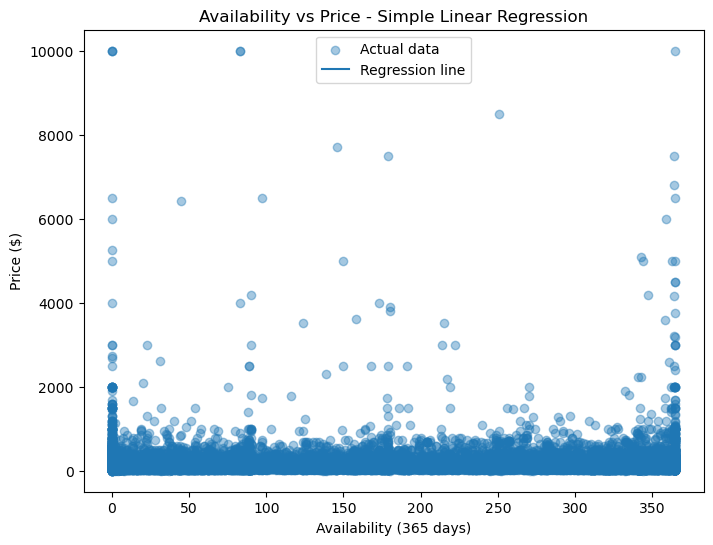

In [56]:
# Q24. Scatter plot with regression line

from sklearn.model_selection import train_test_split

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple,
    y_simple,
    test_size=0.20,
    random_state=42
)

simple_model_train = LinearRegression()

simple_model_train.fit(
    X_train_simple,
    y_train_simple
)

y_line = simple_model_train.predict(X_train_simple)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_simple['availability_365'],
    y_train_simple,
    alpha=0.4,
    label='Actual data'
)

plt.plot(
    X_train_simple['availability_365'],
    y_line,
    label='Regression line'
)

plt.xlabel('Availability (365 days)')
plt.ylabel('Price ($)')
plt.title('Availability vs Price - Simple Linear Regression')
plt.legend()
plt.show()

In [57]:
# Q25. Multiple Linear Regression

multiple_model = LinearRegression()

multiple_model.fit(X_train, y_train)

y_pred_multiple = multiple_model.predict(X_test)

print("Multiple Linear Regression model trained successfully.")

Multiple Linear Regression model trained successfully.


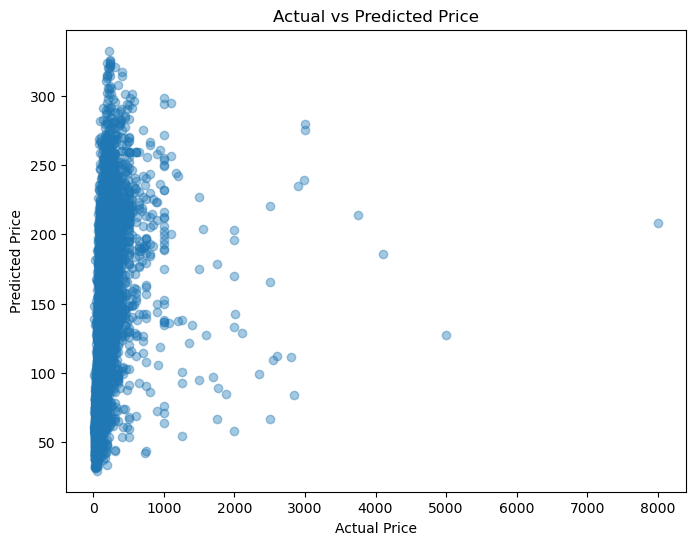

In [58]:
# Q25. Actual vs Predicted prices

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_original,
    y_pred_original,
    alpha=0.4
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')

plt.show()

In [59]:
# Show all coefficients

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': multiple_model.coef_
})

coefficients

,Feature,Coefficient
0,latitude,-0.573967
1,longitude,-3.044055
2,minimum_nights,-0.092994
3,number_of_reviews,-0.030320
4,reviews_per_month,-0.026189
5,calculated_host_listings_count,0.006728
6,availability_365,0.117083
7,room_type_Private room,-0.761769
8,room_type_Shared room,-1.169183
9,neighbourhood_group_Brooklyn,-0.033519


In [51]:
# Q27. Feature coefficients

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
10,neighbourhood_group_Manhattan,0.277095
6,availability_365,0.117083
11,neighbourhood_group_Queens,0.085961
5,calculated_host_listings_count,0.006728
4,reviews_per_month,-0.026189
3,number_of_reviews,-0.030320
9,neighbourhood_group_Brooklyn,-0.033519
2,minimum_nights,-0.092994
0,latitude,-0.573967
7,room_type_Private room,-0.761769


In [60]:
coefficients['Absolute_Coefficient'] = coefficients['Coefficient'].abs()

coefficients.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

,Feature,Coefficient,Absolute_Coefficient
1,longitude,-3.044055,3.044055
8,room_type_Shared room,-1.169183,1.169183
12,neighbourhood_group_Staten Island,-0.815266,0.815266
7,room_type_Private room,-0.761769,0.761769
0,latitude,-0.573967,0.573967
10,neighbourhood_group_Manhattan,0.277095,0.277095
6,availability_365,0.117083,0.117083
2,minimum_nights,-0.092994,0.092994
11,neighbourhood_group_Queens,0.085961,0.085961
9,neighbourhood_group_Brooklyn,-0.033519,0.033519


In [61]:
# Q26. Four features with the largest absolute coefficients

top_4 = coefficients.sort_values(
    by='Absolute_Coefficient',
    ascending=False
).head(4)

top_4

,Feature,Coefficient,Absolute_Coefficient
1,longitude,-3.044055,3.044055
8,room_type_Shared room,-1.169183,1.169183
12,neighbourhood_group_Staten Island,-0.815266,0.815266
7,room_type_Private room,-0.761769,0.761769


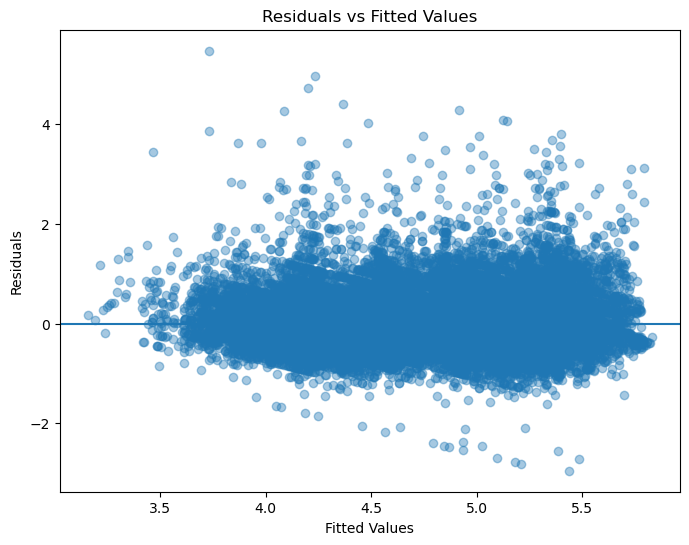

In [62]:
# Q27(a). Residual plot

residuals = y_train - multiple_model.predict(X_train)
fitted_values = multiple_model.predict(X_train)

plt.figure(figsize=(8, 6))

plt.scatter(
    fitted_values,
    residuals,
    alpha=0.4
)

plt.axhline(0)

plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')

plt.show()

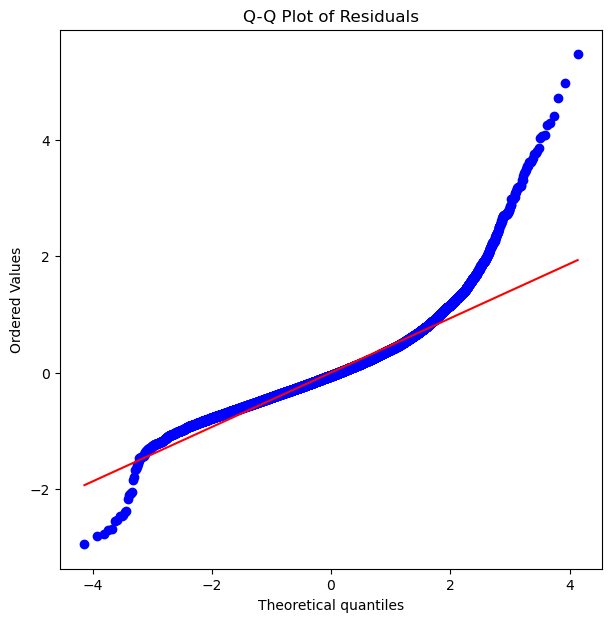

In [63]:
# Q27(b). Q-Q plot

import scipy.stats as stats

plt.figure(figsize=(7, 7))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title('Q-Q Plot of Residuals')
plt.show()

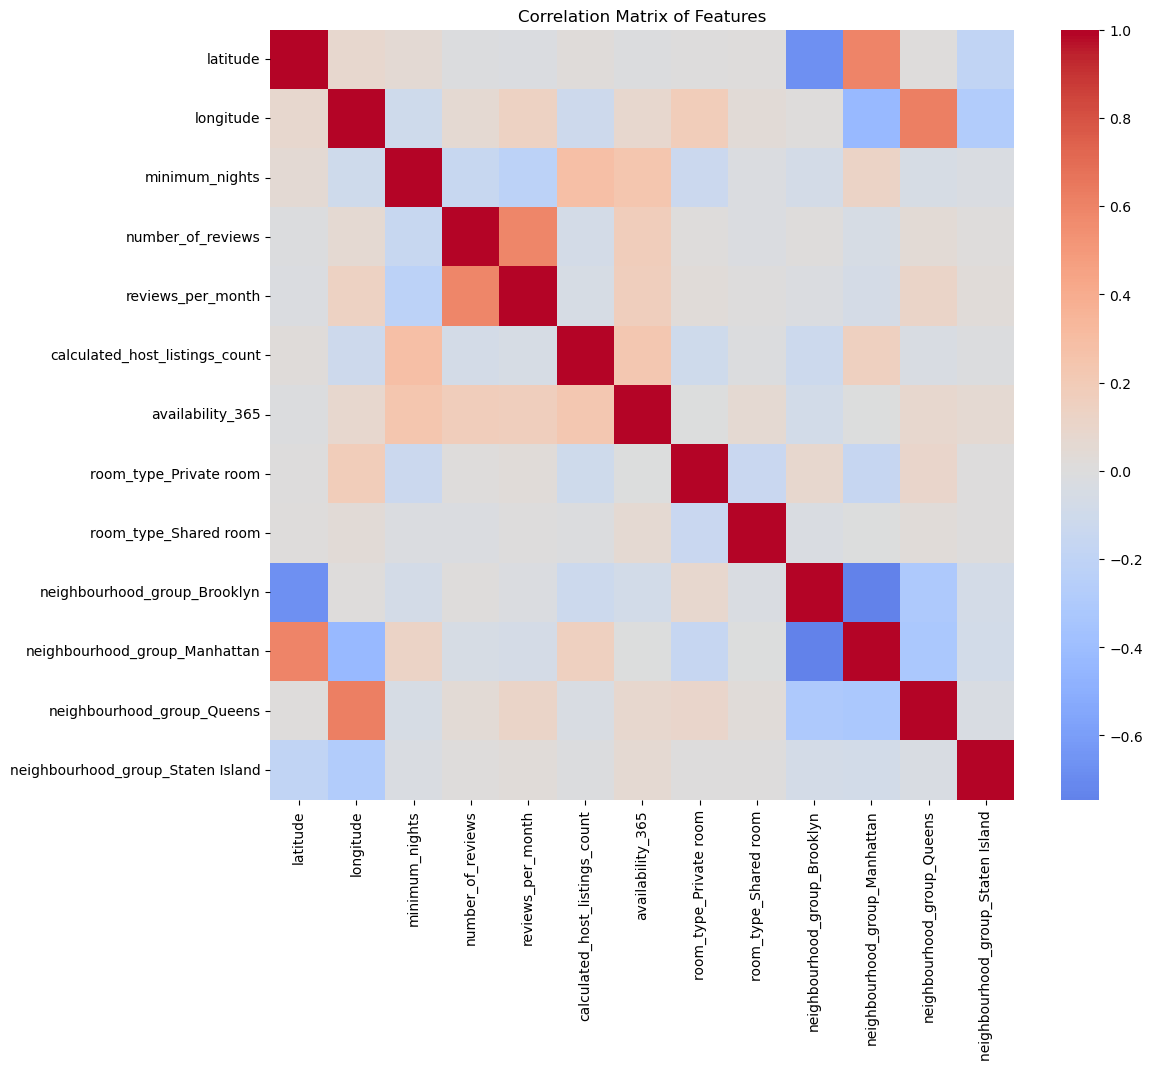

In [64]:
# Q27(c). Correlation matrix

plt.figure(figsize=(12, 10))

sns.heatmap(
    X_train.corr(),
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Features')
plt.show()

### Part E

In [65]:
# Q28. Predictions for both models

simple_pred = simple_model_train.predict(X_test_simple)

multiple_pred = multiple_model.predict(X_test)

In [66]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# R²

simple_r2 = r2_score(y_test_simple, simple_pred)

multiple_r2 = r2_score(y_test, multiple_pred)

print("Simple Model R²:", simple_r2)
print("Multiple Model R²:", multiple_r2)

Simple Model R²: 0.01018706989081386
Multiple Model R²: 0.487310626379035


In [67]:
# Adjusted R²

n_simple = len(X_test_simple)
p_simple = X_test_simple.shape[1]

adjusted_r2_simple = 1 - (
    (1 - simple_r2) * (n_simple - 1) /
    (n_simple - p_simple - 1)
)

n_multiple = len(X_test)
p_multiple = X_test.shape[1]

adjusted_r2_multiple = 1 - (
    (1 - multiple_r2) * (n_multiple - 1) /
    (n_multiple - p_multiple - 1)
)

print("Simple Adjusted R²:", adjusted_r2_simple)
print("Multiple Adjusted R²:", adjusted_r2_multiple)

Simple Adjusted R²: 0.010085810256019956
Multiple Adjusted R²: 0.4866279507816702


In [68]:
# Simple model errors

simple_mae = mean_absolute_error(
    y_test_simple,
    simple_pred
)

simple_rmse = np.sqrt(
    mean_squared_error(
        y_test_simple,
        simple_pred
    )
)

print("Simple MAE:", simple_mae)
print("Simple RMSE:", simple_rmse)

Simple MAE: 90.45179648548492
Simple RMSE: 199.06807918100873


In [69]:
# Q28. Comparison table

comparison = pd.DataFrame({
    'Model': ['Simple Regression', 'Multiple Regression'],
    'R²': [simple_r2, multiple_r2],
    'Adjusted R²': [
        adjusted_r2_simple,
        adjusted_r2_multiple
    ]
})

comparison

,Model,R²,Adjusted R²
0,Simple Regression,0.010187,0.010086
1,Multiple Regression,0.487311,0.486628


In [72]:
# Q29. Convert log(price) back to original price

multiple_pred_original = np.expm1(multiple_pred)
multiple_actual_original = np.expm1(y_test)

# Calculate MAE
multiple_mae_original = mean_absolute_error(
    multiple_actual_original,
    multiple_pred_original
)

# Calculate RMSE
multiple_rmse_original = np.sqrt(
    mean_squared_error(
        multiple_actual_original,
        multiple_pred_original
    )
)

print("Multiple Regression MAE ($):", round(multiple_mae_original, 2))
print("Multiple Regression RMSE ($):", round(multiple_rmse_original, 2))

Multiple Regression MAE ($): 61.59
Multiple Regression RMSE ($): 188.62


In [73]:
# Q30. Calculate Adjusted R²

# Simple Regression
n_simple = len(y_test_simple)
p_simple = X_test_simple.shape[1]

simple_adj_r2 = 1 - (
    (1 - simple_r2) * (n_simple - 1)
    / (n_simple - p_simple - 1)
)

# Multiple Regression
n_multiple = len(y_test)
p_multiple = X_test.shape[1]

multiple_adj_r2 = 1 - (
    (1 - multiple_r2) * (n_multiple - 1)
    / (n_multiple - p_multiple - 1)
)

In [74]:
# Comparison table

final_comparison = pd.DataFrame({
    'Model': [
        'Simple Regression',
        'Multiple Regression'
    ],
    'R²': [
        simple_r2,
        multiple_r2
    ],
    'Adjusted R²': [
        simple_adj_r2,
        multiple_adj_r2
    ],
    'MAE ($)': [
        simple_mae,
        multiple_mae_original
    ],
    'RMSE ($)': [
        simple_rmse,
        multiple_rmse_original
    ]
})

final_comparison.round(2)

,Model,R²,Adjusted R²,MAE ($),RMSE ($)
0,Simple Regression,0.01,0.01,90.45,199.07
1,Multiple Regression,0.49,0.49,61.59,188.62


In [75]:
# Compare R²

if multiple_r2 > simple_r2:
    print("Multiple Regression performs better based on R².")
else:
    print("Simple Regression performs better based on R².")

Multiple Regression performs better based on R².


In [76]:
# Q31. 5-Fold Cross-Validation

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    multiple_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("R² scores for each fold:")
print(cv_scores)

print("\nMean R²:", round(cv_scores.mean(), 2))
print("Standard Deviation:", round(cv_scores.std(), 2))

R² scores for each fold:
[0.51861345 0.50305673 0.51156207 0.50208409 0.4925398 ]

Mean R²: 0.51
Standard Deviation: 0.01


### Part F

#### Ans 32

Room type and location have a strong effect on Airbnb price. In general, entire homes/apartments and listings in expensive areas can charge higher prices

#### Ans 33

One limitation is that the model does not include important factors such as photos and amenities. In a future study, we could add these features to improve the model.